Júlia Monteiro Santos 
JOHNSON & JOHNSON (JNJ)

1. Data Preparation

In [95]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# historical data for Johnson & Johnson yfinance
ticker = "JNJ"
data = yf.download(ticker, start="2021-01-01", end="2026-09-09")

#first and last rows
data.head(), data.tail()

[*********************100%***********************]  1 of 1 completed


(Price            Close        High         Low        Open    Volume
 Ticker             JNJ         JNJ         JNJ         JNJ       JNJ
 Date                                                                
 2021-01-04  133.628342  134.379738  131.604709  134.260199  11765900
 2021-01-05  135.199417  135.558035  132.407320  133.414863   9602300
 2021-01-06  136.471695  136.813232  133.816204  134.260213   8230100
 2021-01-07  136.932724  137.496271  135.207946  135.762947   7747200
 2021-01-08  136.650955  137.556052  136.514348  137.052268   8228900,
 Price            Close        High         Low        Open   Volume
 Ticker             JNJ         JNJ         JNJ         JNJ      JNJ
 Date                                                               
 2026-09-01  271.190002  271.910004  267.019989  270.829987  6033600
 2026-09-02  275.209991  281.070007  273.529999  274.739990  7910600
 2026-09-03  278.429993  278.890015  273.160004  277.320007  5940300
 2026-09-04  275.230011  

In [96]:
#column names simple
data.columns = data.columns.get_level_values(0)

In [97]:
# To have only Closing Price and Volume
data = data[["Close", "Volume"]]

# Create SMA 20 and SMA 50
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()

data.head()

Price,Close,Volume,SMA_20,SMA_50
Date,,,,
2021-01-04,133.628342,11765900,NaN,NaN
2021-01-05,135.199417,9602300,NaN,NaN
2021-01-06,136.471695,8230100,NaN,NaN
2021-01-07,136.932724,7747200,NaN,NaN
2021-01-08,136.650955,8228900,NaN,NaN


In [98]:
# Remove missing values
data = data.dropna()
data.head()

Price,Close,Volume,SMA_20,SMA_50
Date,,,,
2021-03-16,138.645798,6369100,137.294579,138.341182
2021-03-17,138.130295,6001400,137.128612,138.431221
2021-03-18,137.872559,4801800,136.946343,138.484684
2021-03-19,137.503052,14891500,136.863431,138.505311
2021-03-22,137.898300,7544100,136.804575,138.524622


In [99]:
# Check that there are no missing values
data.isnull().sum()

Price
Close     0
Volume    0
SMA_20    0
SMA_50    0
dtype: int64

2. Define the Prediction Problem

In [100]:
# Define the input variables (X)
X = data[["Close", "Volume", "SMA_20", "SMA_50"]].iloc[:-1]

X.head()

Price,Close,Volume,SMA_20,SMA_50
Date,,,,
2021-03-16,138.645798,6369100,137.294579,138.341182
2021-03-17,138.130295,6001400,137.128612,138.431221
2021-03-18,137.872559,4801800,136.946343,138.484684
2021-03-19,137.503052,14891500,136.863431,138.505311
2021-03-22,137.898300,7544100,136.804575,138.524622


In [101]:
# Define the target (y): next period's closing price
y = data["Close"].iloc[1:]

y.head()

Date
2021-03-17    138.130295
2021-03-18    137.872559
2021-03-19    137.503052
2021-03-22    137.898300
2021-03-23    137.769424
Name: Close, dtype: float64

In [102]:
# Check that X & Y have the same number of observations
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1376, 4)
y shape: (1376,)


4.Split the Data

In [103]:
# Calculate the 80% split point
split = int(len(X) * 0.80)

split

1100

In [104]:
# Split the data into 80% training and 20% testing
X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [105]:
# Check the size of the training and testing sets
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1100, 4)
X_test: (276, 4)
y_train: (1100,)
y_test: (276,)


3.Normalize the Data(after train/test split)

In [106]:
# Calculate mean and standard deviation from training data
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

In [107]:
# Normalize training and testing data
X_train_normalized = (X_train - X_mean) / X_std
X_test_normalized = (X_test - X_mean) / X_std

y_train_normalized = (y_train - y_mean) / y_std
y_test_normalized = (y_test - y_mean) / y_std

In [108]:
# Show the normalized training variables
X_train_normalized.head()

Price,Close,Volume,SMA_20,SMA_50
Date,,,,
2021-03-16,-1.405485,-0.232835,-1.738054,-1.772659
2021-03-17,-1.484043,-0.277414,-1.765878,-1.755222
2021-03-18,-1.523319,-0.422852,-1.796434,-1.744868
2021-03-19,-1.579628,0.800405,-1.810334,-1.740874
2021-03-22,-1.519396,-0.090380,-1.820201,-1.737134


In [109]:
# Show the normalized target values
y_train_normalized.head()

Date
2021-03-17   -1.485348
2021-03-18   -1.524572
2021-03-19   -1.580805
2021-03-22   -1.520654
2021-03-23   -1.540267
Name: Close, dtype: float64

5. Build the Neural Network

In [110]:
# Import the neural network model
from sklearn.neural_network import MLPRegressor

In [111]:
# Build the neural network
model = MLPRegressor(
    hidden_layer_sizes=(20,),
    max_iter=1000,
    random_state=1
)

In [112]:
# Train the neural network
model.fit(X_train_normalized, y_train_normalized)

MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000, random_state=1)

6. Generate Predictions

In [113]:
# Generate predictions for the testing period
y_pred_normalized = model.predict(X_test_normalized)

In [114]:
# Convert predictions back to the original price scale
y_pred = y_pred_normalized * y_std + y_mean

In [115]:
# Compare actual and predicted closing prices
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [116]:
comparison.head()

,Actual,Predicted
Date,,
2025-08-04,166.051590,161.588110
2025-08-05,165.760361,164.328049
2025-08-06,165.614716,163.914129
2025-08-07,166.527298,164.001904
2025-08-08,168.274811,164.726936


7. Evaluate the Model

In [117]:
# Import the metrics used to evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [118]:
# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [119]:
# Show the model evaluation results
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 12.486929379072421
MAE: 10.974647210382358


8. Create a Visualization

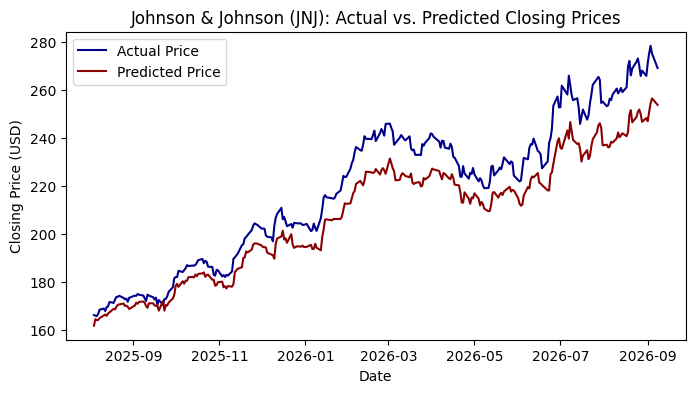

In [120]:
# Add graph with the size title, axis labels, legend and colors
plt.figure(figsize=(8,4))

plt.plot(y_test.index, y_test.values, label="Actual Price", color="darkblue")
plt.plot(y_test.index, y_pred, label="Predicted Price", color="darkred")

plt.title("Johnson & Johnson (JNJ): Actual vs. Predicted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()

plt.show()

9. Compare the Neural Network Against a Simple Benchmark

In [121]:
# Create the simple benchmark: tomorrow's price equals today's price
benchmark_pred = X_test["Close"].values

In [122]:
# Calculate the RMSE of the benchmark
benchmark_rmse = np.sqrt(mean_squared_error(y_test, benchmark_pred))

In [123]:
# Compare the neural network RMSE with the benchmark RMSE
print("Neural Network RMSE:", rmse)
print("Benchmark RMSE:", benchmark_rmse)

Neural Network RMSE: 12.486929379072421
Benchmark RMSE: 2.7299526564611107


10.Financial Interpretation

Answer in report.


